In [1]:
import numpy as np
import pickle
import torch
from torch.utils.data import DataLoader, TensorDataset,  random_split
from typing import Union
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch

In [2]:
from general_utils import General, Metrics
from train import train
from unet.models import UNet, AttentionUNet
from dataset import TIFFSegmentationDataset
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Subset

## **CARGA REAL**

In [5]:
# Retrieve data 
dataset = TIFFSegmentationDataset(
    img_dir=r"./dataset/TIFF Images",
    mask_dir=r"./dataset/ROI Masks",
    patch_size=1024)

# Define train and test split sizes
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset)- (train_size + val_size)
# Define the splits and store them only once
path_data = './data'
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
General.serialize_data(train_dataset, path_data,  name = 'train.pkl')
General.serialize_data(val_dataset, path_data,  name = 'val.pkl')
General.serialize_data(test_dataset, path_data, name = 'test.pkl')

The dir (./data) exists
The dir (./data) exists
The dir (./data) exists


## **DEPURACIÓN CON OXFORD**

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms.functional as TF
import random

# --- Transformaciones sincronizadas ---
class JointTransform:
    def __init__(self, size=(256, 256)):
        self.size = size

    def __call__(self, img, mask):
        # Resize
        img = TF.resize(img, self.size)
        mask = TF.resize(mask, self.size, interpolation=TF.InterpolationMode.NEAREST)

        # Random horizontal flip (sincronizado)
        if random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # A tensor
        img = TF.to_tensor(img)

        # Mascara: convertir a tensor SIN normalizar
        mask = torch.as_tensor(TF.pil_to_tensor(mask), dtype=torch.long)

        # Oxford Pets: clases {1,2,3} → fondo/objeto/borde
        # Para binario: objeto = 1, resto = 0
        mask = (mask == 1).long()

        return img, mask


# --- Dataset wrapper ---
class OxfordPetSegmentation(torch.utils.data.Dataset):
    def __init__(self, root, split="trainval", transform=None):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]

        if self.transform:
            img, mask = self.transform(img, mask)

        return img, mask


# --- Crear dataset y dataloader ---
transform = JointTransform(size=(256, 256))

train_dataset = OxfordPetSegmentation(
    root="./data",
    split="trainval",
    transform=transform
)


100%|██████████| 792M/792M [07:18<00:00, 1.81MB/s]  
100%|██████████| 19.2M/19.2M [00:10<00:00, 1.87MB/s]


In [10]:
torch.manual_seed(0)

# --- Dataset completo ---
full_train_dataset = OxfordPetSegmentation(root="./data", split="trainval", transform=transform)
test_dataset       = OxfordPetSegmentation(root="./data", split="test",     transform=transform)

# --- Splits train/val ---
n_total = len(full_train_dataset)  # ~3680
n_val   = int(n_total * 0.15)      # ~552
n_train = n_total - n_val          # ~3128

indices     = torch.randperm(n_total)
train_subset = Subset(full_train_dataset, indices[:n_train])
val_subset   = Subset(full_train_dataset, indices[n_train:])

# --- Dataloaders ---
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_dataloader   = DataLoader(val_subset,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_dataloader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}')

Train: 3128 | Val: 552 | Test: 3669


## **TRAIN**

In [6]:
def dice(pred, target, smooth = 1e-16):

    pred = torch.sigmoid(pred)
    pred = pred.view(pred.shape[0], pred.shape[1], -1)
    target = target.view(target.shape[0], target.shape[1], -1)
    #print(pred.shape, target.shape)

    intersection = (pred*target).sum(dim = 2)
    union = pred.sum(dim=2) + target.sum(dim=2)
    dice = (2*intersection + smooth)/(union+smooth)

    return (1-dice).mean()

In [11]:
def combined_loss(output, labels, bce_criterion, dice_weight=0.3):
    """BCE + Dice loss combinadas"""
    bce = bce_criterion(output, labels)
    
    # Dice sobre probabilidades
    probs = torch.sigmoid(output)
    smooth = 1.
    intersection = (probs * labels).sum(dim=(1,2,3))
    dice_loss = 1 - (2. * intersection + smooth) / (
        probs.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3)) + smooth
    )
    return (1 - dice_weight) * bce + dice_weight * dice_loss.mean()

In [12]:
def train(modelname:str, val_loader, model:Union[UNet], dataloader:DataLoader, epochs:int, device:str, path:str, weight:float, thres = 0.01)->list[float]:
    """ 
        Function aimed to train the given model 
        over a given dataset

        Params:
            modelname(str): The name of the model
            model(Union[UNet, AttentionUnet]): The selected model
            dataloader(DataLoader): The object to sample batches from
            epochs(int): The number of epochs
            device(str): Define the device to use
            PATH(str): Model's storing path
            weight(float): The positive class weight

        Returns:
            loss(list[float]): The loss evolution
    """

    # Define mode and loss
    scaler = torch.amp.GradScaler('cuda')
    model.to(device)
    model.train()
    weigth_tensor = torch.tensor(weight).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight = weigth_tensor)
    optimizer = optim.Adam(model.parameters(), lr  = 1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

    loss_storage = {}
    #prev_loss = 0

    # Iterate over the different epochs
    for epoch in range(epochs):
        epoch_loss = 0
        batch_loss = 0
        # Information print about the epoch
        print(f'EPOCH({epoch})')

        # Run each batch
        for i, batch in enumerate(dataloader):
 
            # Divide between input and data
            data, labels = batch
            # Matching the device
            data = data.to(device)
            labels = labels.to(device).float()
            
    
            # Set gradients to zero per batch
            optimizer.zero_grad()

            # Switching to automatic mixed precission
            with torch.amp.autocast('cuda'):
                # Make predictions for the batch
                output = model(data)
                # Compute loss and gradients
                loss = combined_loss(output, labels, criterion, dice_weight=0.5)

            # Scales loss. Calls backward() on scaled loss to create scaled gradients.
            scaler.scale(loss).backward()

            # Perform an optimizer's step
            scaler.step(optimizer)
            scaler.update()


            # Update data and report
            batch_loss +=loss.item()
            epoch_loss +=loss.item()

            # XBatch information
            if (i+1)%10 == 0:
                avg_loss = batch_loss/10
                print(f"·Batch({i+1}):loss({avg_loss})")
                batch_loss = 0

        # --- VALIDATION ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                data, labels = batch
                data, labels = data.to(device), labels.to(device).float()
                with torch.amp.autocast('cuda'):
                    output = model(data)
                    val_loss += combined_loss(output, labels, criterion, dice_weight=0.5).item()


        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        print(f'Val loss: {avg_val_loss:.4f}')
        
        # Store average loss
        model.train() 
        avg_loss = epoch_loss/len(dataloader)
        loss_storage[epoch] = avg_loss
        print(f'Cumulated loss epoch:{avg_loss}')
        print()
        
        '''if np.abs(avg_val_loss-prev_loss)<thres:
            break
        prev_loss = avg_val_loss
        '''

    
    # Save the trained model
    torch.save(model.state_dict(), f'{path}/{modelname}.pth')  

    # Return
    return loss_storage

In [ ]:
# Retrieve train object
train_dataset = General.recover_data(path_data, name = 'train')

# Generate a DataLoader object for train
train_dataloader = DataLoader(
    train_dataset,
    batch_size=5,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)
# Retrieve val object
val_dataset = General.recover_data(path_data, name = 'val')

# Generate a DataLoader object for train
val_dataloader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

In [ ]:
all_data = DataLoader(
    dataset,
    batch_size=5,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)
weight = General.metametrics(all_data)

In [23]:
# Check model's storing path
path_model = './models'
General.ensure_dir(path_model)

# Compute metametrics for weighting
weight = 2

# Create model and params
model = AttentionUNet(in_channels = 3, num_classes = 1) 
epochs = 5
device = 'cuda'if torch.cuda.is_available() else "cpu"

# Call training with the model
modelname = 'UNET'
loss_values = train(modelname, val_dataloader, model, train_dataloader, epochs, device, path_model, weight)

The dir (./models) exists
EPOCH(0)
·Batch(10):loss(0.750701493024826)
·Batch(20):loss(0.655590683221817)
·Batch(30):loss(0.650677067041397)
·Batch(40):loss(0.616788923740387)
·Batch(50):loss(0.580513870716095)
·Batch(60):loss(0.5928837776184082)
·Batch(70):loss(0.5590169608592988)
·Batch(80):loss(0.5706422805786133)
·Batch(90):loss(0.5442292362451553)
·Batch(100):loss(0.5345457911491394)
·Batch(110):loss(0.5373677760362625)
·Batch(120):loss(0.5171562433242798)
·Batch(130):loss(0.531760859489441)
·Batch(140):loss(0.5004344612360001)
·Batch(150):loss(0.4993261396884918)
·Batch(160):loss(0.5051088988780975)
·Batch(170):loss(0.47960165441036223)
·Batch(180):loss(0.47506304979324343)
·Batch(190):loss(0.48897424042224885)
·Batch(200):loss(0.5081112056970596)
·Batch(210):loss(0.4920144647359848)
·Batch(220):loss(0.4898501992225647)
·Batch(230):loss(0.4513393849134445)
·Batch(240):loss(0.4692185163497925)
·Batch(250):loss(0.4751992136240005)
·Batch(260):loss(0.4194562822580338)
·Batch(270):los

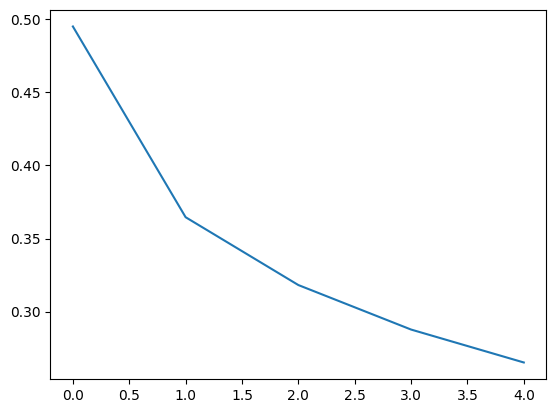

In [24]:
plt.plot(loss_values.values())

## **TEST**

In [19]:
def test(modelname:str, model:Union[UNet], dataloader:DataLoader, device:str, path:str)->dict[str, float]:
    """ 
        Function aimed to provide testing over a given model
        given model 

        Params:
            modelname(str): The name of the model to load
            model(Union[UNet, AttentionUnet]): The given model 
            dataloader(DataLoader): The given dataset
            device(str): Define the device to use
            path(str): The path to load the model from


        Returns:
            metrics(dict[str, float]): The dictionary of metrics
    """


    # Load the model  -> build path adding name
    model_path  = path + f'/{modelname}.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)

    # Set the model to evaluation
    model.eval()

    # Define the storage structures
    prediction_list = []
    labels_list = []

    # Generate the outputs
    with torch.no_grad():
        for data, labels in dataloader:

            data = data.to(device)
            # Get the output from the model 
            logits = model(data).to(device = 'cpu')
            # Get the prediction [0,1]-->sigmoid(logit)
            probability = torch.sigmoid(logits)
            classification = (probability>0.5).float()

            # Store the pair (output, labels)
            prediction_list.append(classification)
            labels_list.append(labels)


    
    # Create structure to feed the metrics class (total, ch, h, w)
    predictions_tensor = torch.cat(prediction_list)
    print(predictions_tensor.shape)
    labels_tensor  = torch.cat(labels_list)

    # Metrics management
    metrics = Metrics(predictions_tensor, labels_tensor)

    # Create the metrics
    metrics.feed_metrics()

    # Show info
    print(metrics)

    return metrics.metrics

In [34]:
# Retrieve train data
path_data = './data'
test_dataset = General.recover_data(path_data, name = 'train')

# Generate a DataLoader object for train
test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [26]:
# Create model and params
model = AttentionUNet(in_channels = 3, num_classes = 1) 
device = 'cuda' if torch.cuda.is_available() else "cpu"
name = 'UNET'

# Call training
metrics_dict = test(name, model, test_dataloader, device, path_model)

torch.Size([3669, 1, 256, 256])
***************
METRICS SUMMARY
***************
·Dice: 0.8328

